In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('student_information.csv')

In [4]:
df.shape

(1044, 33)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1044 entries, 0 to 1043
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      1044 non-null   object
 1   sex         1044 non-null   object
 2   age         1044 non-null   int64 
 3   address     1044 non-null   object
 4   famsize     1044 non-null   object
 5   Pstatus     1044 non-null   object
 6   Medu        1044 non-null   int64 
 7   Fedu        1044 non-null   int64 
 8   Mjob        1044 non-null   object
 9   Fjob        1044 non-null   object
 10  reason      1044 non-null   object
 11  guardian    1044 non-null   object
 12  traveltime  1044 non-null   int64 
 13  studytime   1044 non-null   int64 
 14  failures    1044 non-null   int64 
 15  schoolsup   1044 non-null   object
 16  famsup      1044 non-null   object
 17  paid        1044 non-null   object
 18  activities  1044 non-null   object
 19  nursery     1044 non-null   object
 20  higher  

In [6]:
df.describe(include=[np.number]).T

,count,mean,std,min,25%,50%,75%,max
age,1044.0,16.726054,1.239975,15.0,16.0,17.0,18.0,22.0
Medu,1044.0,2.603448,1.124907,0.0,2.0,3.0,4.0,4.0
Fedu,1044.0,2.387931,1.099938,0.0,1.0,2.0,3.0,4.0
traveltime,1044.0,1.522989,0.731727,1.0,1.0,1.0,2.0,4.0
studytime,1044.0,1.970307,0.834353,1.0,1.0,2.0,2.0,4.0
failures,1044.0,0.264368,0.656142,0.0,0.0,0.0,0.0,3.0
famrel,1044.0,3.935824,0.933401,1.0,4.0,4.0,5.0,5.0
freetime,1044.0,3.201149,1.031507,1.0,3.0,3.0,4.0,5.0
goout,1044.0,3.156130,1.152575,1.0,2.0,3.0,4.0,5.0
Dalc,1044.0,1.494253,0.911714,1.0,1.0,1.0,2.0,5.0


In [7]:
df.head(10)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,55,55
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,45,55,55
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,60,65,60
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,70,70,70
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,55,65,65
5,GP,M,16,U,LE3,T,4,3,services,other,...,5,4,2,1,2,5,6,60,60,65
6,GP,M,16,U,LE3,T,2,2,other,other,...,4,4,4,1,1,3,0,65,60,65
7,GP,F,17,U,GT3,A,4,4,other,teacher,...,4,1,4,1,1,1,2,50,65,65
8,GP,M,15,U,LE3,A,3,2,services,other,...,4,2,2,1,1,1,0,75,80,85
9,GP,M,15,U,GT3,T,3,4,other,other,...,5,5,1,1,1,5,0,60,60,65


In [8]:
df.isnull().sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

In [9]:
def outlier_summary_iqr(df):
    results = []

    numeric_cols = df.select_dtypes(include=[np.number]).columns
    
    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
        
        results.append({
            "Column": col,
            "Outliers Count": len(outliers),
            "Percentage": round((len(outliers) / len(df)) * 100, 2)
        })
    
    result_df = pd.DataFrame(results)
    result_df = result_df.sort_values(by="Outliers Count", ascending=False).reset_index(drop=True)
    
    return result_df

In [10]:
outlier_table = outlier_summary_iqr(df)
print(outlier_table)

        Column  Outliers Count  Percentage
0     failures             183       17.53
1       famrel              77        7.38
2     freetime              64        6.13
3    studytime              62        5.94
4     absences              54        5.17
5           G3              54        5.17
6         Dalc              52        4.98
7   traveltime              24        2.30
8           G2              20        1.92
9          age               2        0.19
10          G1               1        0.10
11        Medu               0        0.00
12        Fedu               0        0.00
13       goout               0        0.00
14        Walc               0        0.00
15      health               0        0.00


In [11]:
gender_name={"F":"Female","M":"Male"}
df["sex"] = df["sex"].map(gender_name)
gender_counts=df["sex"].value_counts()
gender_counts

sex
Female    591
Male      453
Name: count, dtype: int64

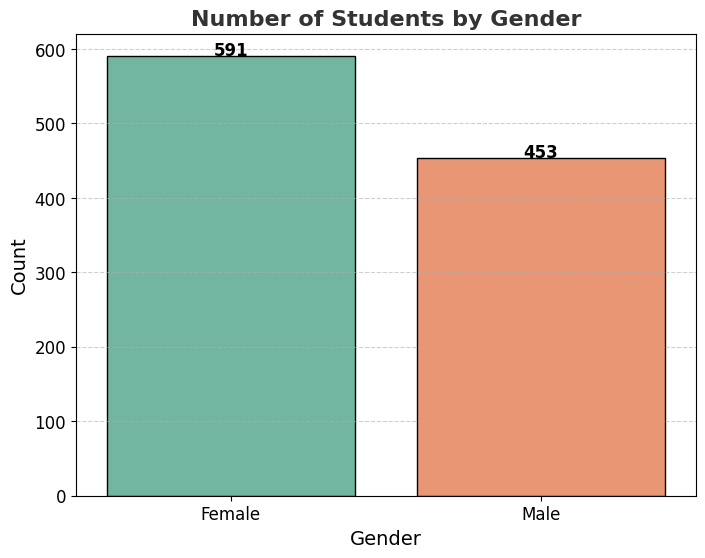

In [12]:
gender_df = gender_counts.reset_index()
gender_df.columns = ["Gender", "Count"]

plt.figure(figsize=(8, 6))
palette = sns.color_palette("Set2", len(gender_df))
sns.barplot(data=gender_df, x="Gender", y="Count", palette=palette, edgecolor="black")

for index, row in gender_df.iterrows():
    plt.text(index, row["Count"] + 1, row["Count"], ha="center", fontsize=12, fontweight="bold")

plt.title("Number of Students by Gender", fontsize=16, fontweight="bold", color="#333333")
plt.xlabel("Gender", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()

In [13]:
for col in df.columns:
    print(col)
    print(df[col].unique())
    print("------")

school
['GP' 'MS']
------
sex
['Female' 'Male']
------
age
[18 17 15 16 19 22 20 21]
------
address
['U' 'R']
------
famsize
['GT3' 'LE3']
------
Pstatus
['A' 'T']
------
Medu
[4 1 3 2 0]
------
Fedu
[4 1 2 3 0]
------
Mjob
['at_home' 'health' 'other' 'services' 'teacher']
------
Fjob
['teacher' 'other' 'services' 'health' 'at_home']
------
reason
['course' 'other' 'home' 'reputation']
------
guardian
['mother' 'father' 'other']
------
traveltime
[2 1 3 4]
------
studytime
[2 3 1 4]
------
failures
[0 3 1 2]
------
schoolsup
['yes' 'no']
------
famsup
['no' 'yes']
------
paid
['no' 'yes']
------
activities
['no' 'yes']
------
nursery
['yes' 'no']
------
higher
['yes' 'no']
------
internet
['no' 'yes']
------
romantic
['no' 'yes']
------
famrel
[4 5 3 1 2]
------
freetime
[3 2 4 1 5]
------
goout
[4 3 2 1 5]
------
Dalc
[1 2 5 3 4]
------
Walc
[1 3 2 4 5]
------
health
[3 5 1 2 4]
------
absences
[ 4  2  6  0 10  8 16 14  1 12 24 22 32 30 21 15  9 18 26  7 11  5 13  3
 25 54 20 56 28 75

In [14]:
print(df.duplicated().sum())

0


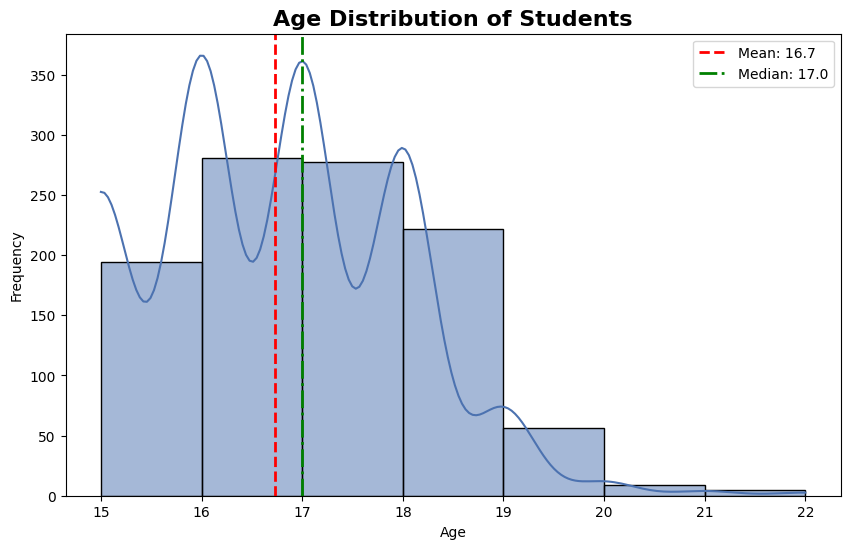

In [15]:
plt.figure(figsize=(10,6))
sns.histplot(df["age"], bins=7, kde=True, color="#4C72B0", edgecolor="black")
plt.axvline(df["age"].mean(), color="red", linestyle="--", linewidth=2, label=f"Mean: {df['age'].mean():.1f}")
plt.axvline(df["age"].median(), color="green", linestyle="-.", linewidth=2, label=f"Median: {df['age'].median():.1f}")
plt.title("Age Distribution of Students", fontsize=16, fontweight="bold")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.legend()
plt.show()

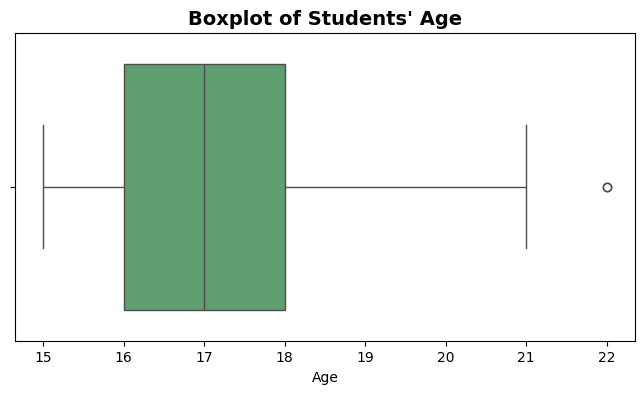

In [16]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df["age"], color="#55A868")
plt.title("Boxplot of Students' Age", fontsize=14, fontweight="bold")
plt.xlabel("Age")
plt.show()

In [17]:
df["address"].value_counts()

address
U    759
R    285
Name: count, dtype: int64

In [18]:
adress={"U":"Urban","R":"Rural"}
df["address"]=df["address"].map(adress)
area_counts=df["address"].value_counts()
area_counts

address
Urban    759
Rural    285
Name: count, dtype: int64

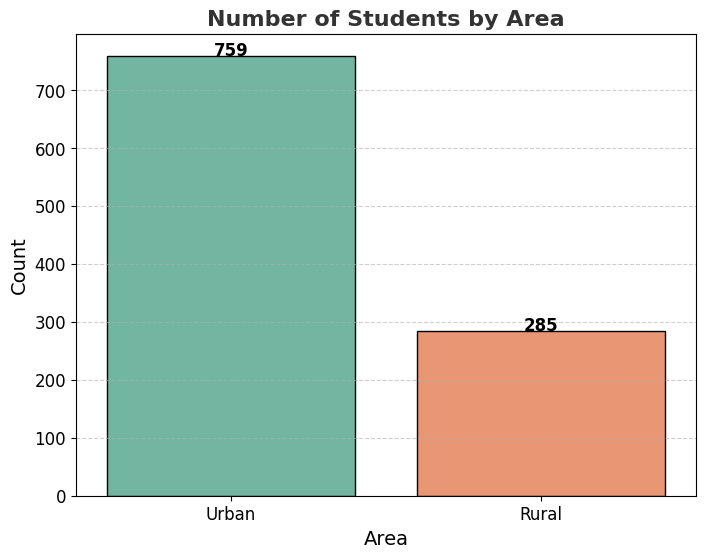

In [19]:
area_df = area_counts.reset_index()
area_df.columns = ["Area", "Count"]

plt.figure(figsize=(8, 6))
palette = sns.color_palette("Set2", len(area_df))
sns.barplot(data=area_df, x="Area", y="Count", palette=palette, edgecolor="black")

for index, row in area_df.iterrows():
    plt.text(index, row["Count"] + 1, row["Count"], ha="center", fontsize=12, fontweight="bold")

plt.title("Number of Students by Area", fontsize=16, fontweight="bold", color="#333333")
plt.xlabel("Area", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()

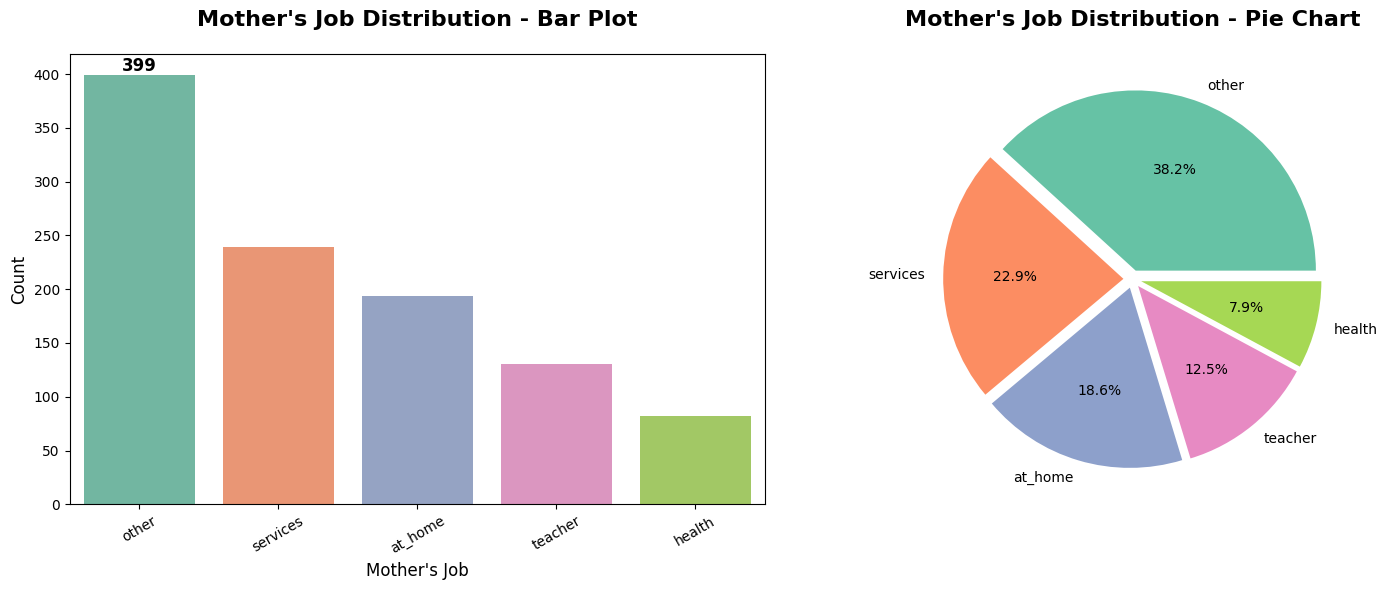

In [20]:
Mjob_counts = df["Mjob"].value_counts()
plt.figure(figsize=(15,6))
plt.subplot(1,2,1)
ax = sns.countplot(data=df, x="Mjob", order=Mjob_counts.index, palette="Set2")
ax.bar_label(ax.containers[0], fontweight="bold", size=12)
plt.title("Mother's Job Distribution - Bar Plot", fontweight="bold", size=16, pad=20)
plt.xlabel("Mother's Job", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=30)
plt.subplot(1,2,2)
plt.pie(
    Mjob_counts.values, 
    labels=Mjob_counts.index, 
    autopct="%1.1f%%", 
    explode=[0.05]*len(Mjob_counts), 
    colors=sns.color_palette("Set2")
)
plt.title("Mother's Job Distribution - Pie Chart", fontweight="bold", size=16, pad=20)

plt.tight_layout()
plt.show()

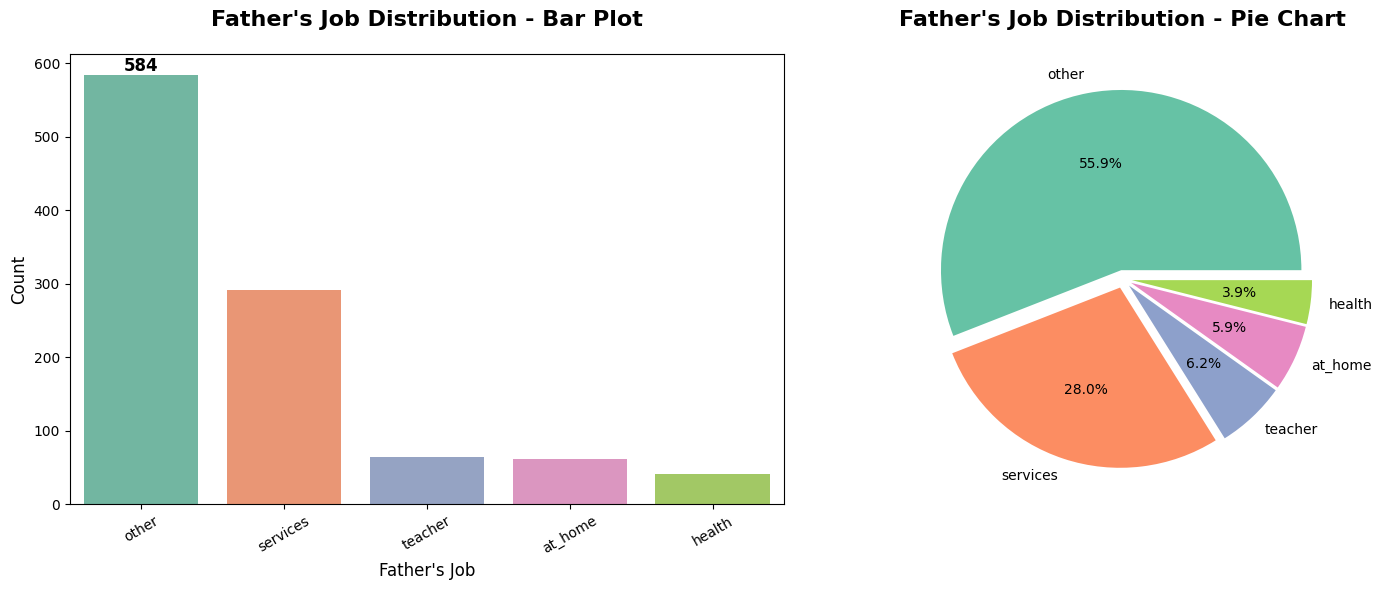

In [21]:
Fjob_counts = df["Fjob"].value_counts()
plt.figure(figsize=(15,6))
plt.subplot(1,2,1)
ax = sns.countplot(data=df, x="Fjob", order=Fjob_counts.index, palette="Set2")
ax.bar_label(ax.containers[0], fontweight="bold", size=12)
plt.title("Father's Job Distribution - Bar Plot", fontweight="bold", size=16, pad=20)
plt.xlabel("Father's Job", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=30)
plt.subplot(1,2,2)
plt.pie(
    Fjob_counts.values, 
    labels=Fjob_counts.index, 
    autopct="%1.1f%%", 
    explode=[0.05]*len(Fjob_counts), 
    colors=sns.color_palette("Set2")
)
plt.title("Father's Job Distribution - Pie Chart", fontweight="bold", size=16, pad=20)

plt.tight_layout()
plt.show()

In [22]:
traveltime_mapping = {
    1: "< 15 less than ",
    2: "15-30 between",
    3: "30-60 between",
    4: "> 60 more than "
}
df["traveltime"] = df["traveltime"].map(traveltime_mapping)
traveltime_counts=df["traveltime"].value_counts()
traveltime_counts

traveltime
< 15 less than     623
15-30 between      320
30-60 between       77
> 60 more than      24
Name: count, dtype: int64

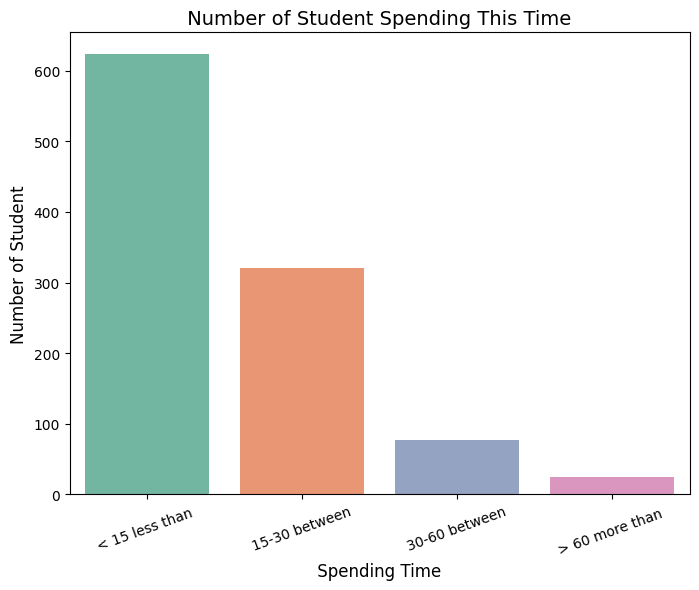

In [23]:
plt.figure(figsize=(8,6))
sns.barplot(
    x=traveltime_counts.index, 
    y=traveltime_counts.values, 
    palette="Set2"
)

plt.title(" Number of Student Spending This Time ", fontsize=14)
plt.xlabel(" Spending Time ", fontsize=12)
plt.ylabel("Number of Student", fontsize=12)
plt.xticks(rotation=20)
plt.show()

In [24]:
studytime_mapping = {
    1: "<2 hours",
    2: "2–5 hours",
    3: "5–10 hours",
    4: ">10 hours"
}
df["studytime"] = df["studytime"].map(studytime_mapping)
studytime_counts = df["studytime"].value_counts()
studytime_counts

studytime
2–5 hours     503
<2 hours      317
5–10 hours    162
>10 hours      62
Name: count, dtype: int64

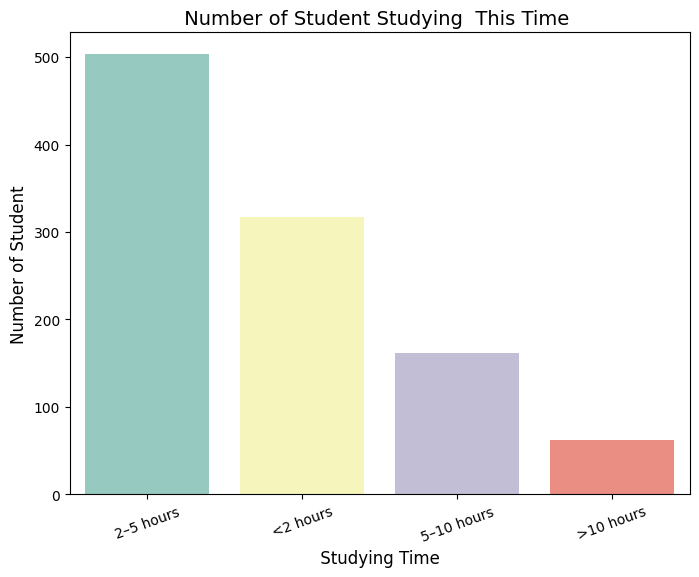

In [25]:
plt.figure(figsize=(8,6))
sns.barplot(
    x=studytime_counts.index, 
    y=studytime_counts.values, 
    palette="Set3"
)

plt.title(" Number of Student Studying  This Time  ", fontsize=14)
plt.xlabel(" Studying Time ", fontsize=12)
plt.ylabel("Number of Student", fontsize=12)
plt.xticks(rotation=20)
plt.show()

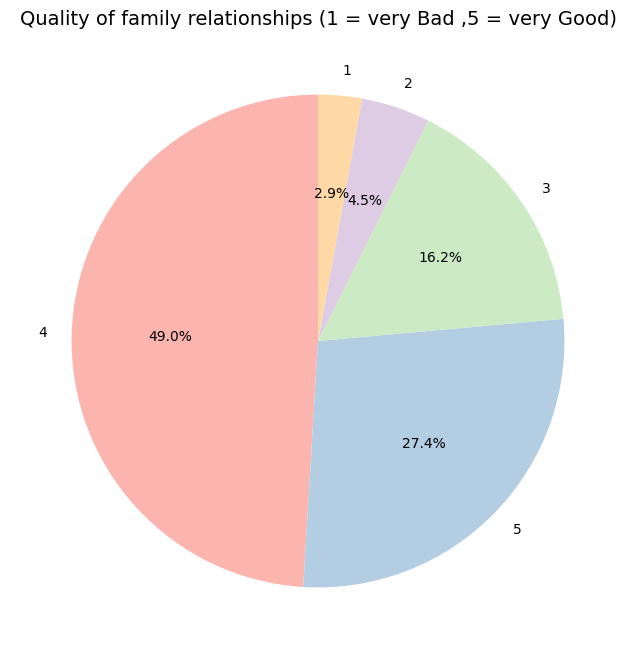

In [26]:
fc=df["famrel"].value_counts()
plt.figure(figsize=(10,8))
plt.pie(
    fc,
    labels=fc.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=plt.cm.Pastel1.colors
)

plt.title("Quality of family relationships (1 = very Bad ,5 = very Good)", fontsize=14)
plt.show()

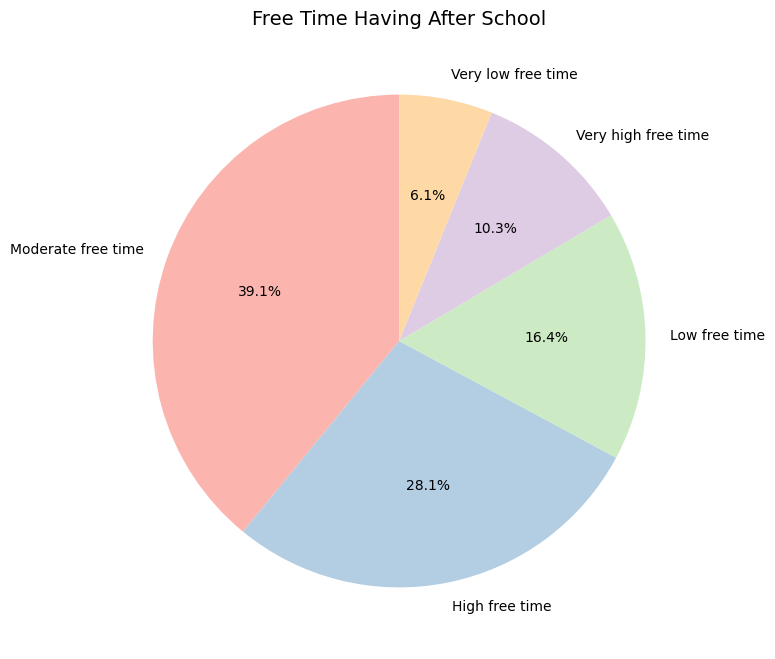

In [27]:
freetime_mapping = {
    1: "Very low free time",
    2: "Low free time",
    3: "Moderate free time",
    4: "High free time",
    5: "Very high free time"
}
df["freetime"] = df["freetime"].map(freetime_mapping)

frc=df["freetime"].value_counts()
plt.figure(figsize=(10,8))
plt.pie(
    frc,
    labels=frc.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=plt.cm.Pastel1.colors
)

plt.title("Free Time Having After School", fontsize=14)
plt.show()

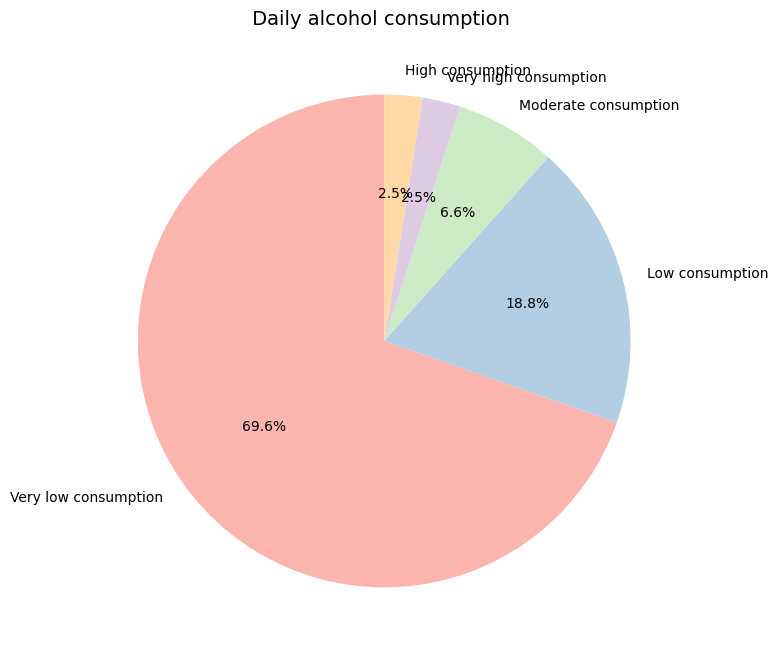

In [28]:
dalc_mapping = {
    1: "Very low consumption",
    2: "Low consumption",
    3: "Moderate consumption",
    4: "High consumption",
    5: "Very high consumption"
}
df["Dalc"] = df["Dalc"].map(dalc_mapping)

dc=df["Dalc"].value_counts()
plt.figure(figsize=(10,8))
plt.pie(
    dc,
    labels=dc.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=plt.cm.Pastel1.colors
)

plt.title(" Daily alcohol consumption  ", fontsize=14)
plt.show()


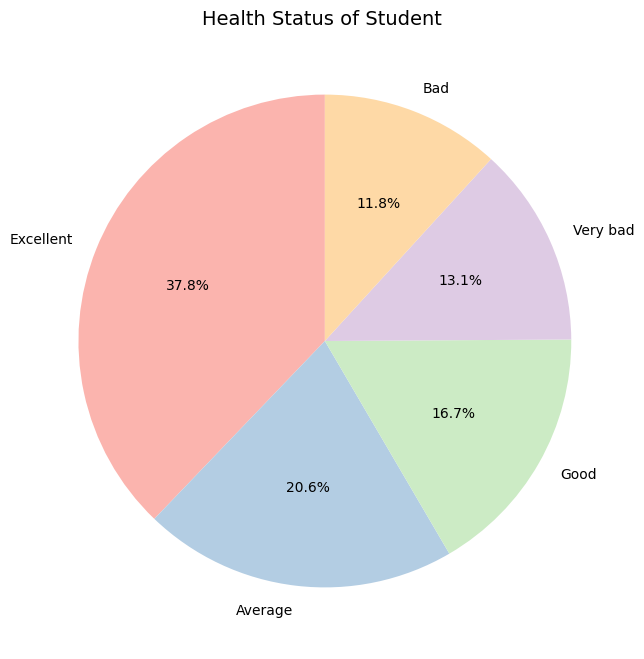

In [29]:
health_mapping = {
    1: "Very bad",
    2: "Bad",
    3: "Average",
    4: "Good",
    5: "Excellent"
}
df["health"]=df["health"].map(health_mapping)
hc=df["health"].value_counts()
plt.figure(figsize=(10,8))
plt.pie(
    hc,
    labels=hc.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=plt.cm.Pastel1.colors
)

plt.title("Health Status of Student ", fontsize=14)
plt.show()

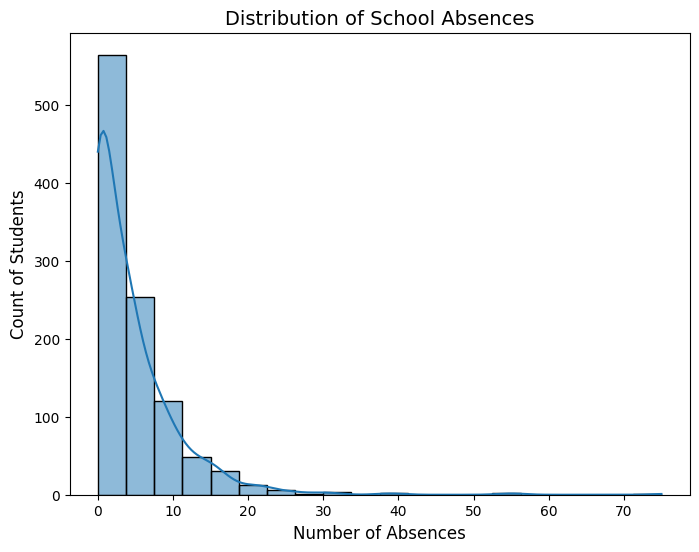

In [30]:
plt.figure(figsize=(8,6))
sns.histplot(df["absences"], bins=20, kde=True)

plt.title("Distribution of School Absences", fontsize=14)
plt.xlabel("Number of Absences", fontsize=12)
plt.ylabel("Count of Students", fontsize=12)
plt.show()

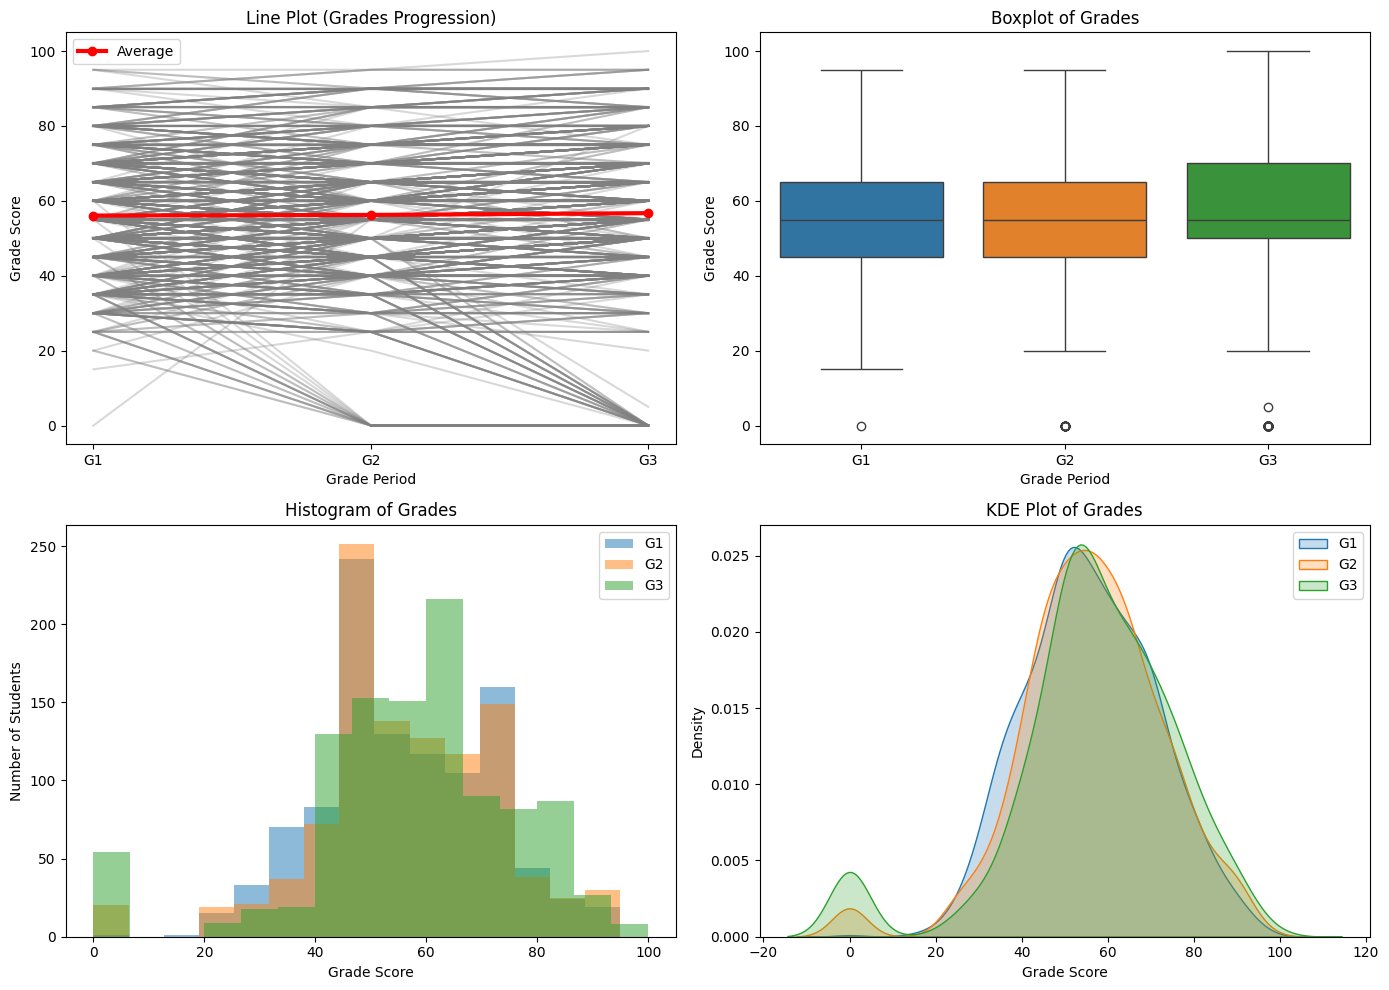

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(14,10))
axes[0,0].plot(df[["G1","G2","G3"]].T, color="gray", alpha=0.3)
axes[0,0].plot(["G1","G2","G3"], 
             df[["G1","G2","G3"]].mean(), 
             color="red", linewidth=3, marker="o", label="Average")
axes[0,0].set_title("Line Plot (Grades Progression)")
axes[0,0].set_xlabel("Grade Period")
axes[0,0].set_ylabel("Grade Score")
axes[0,0].legend()

sns.boxplot(data=df[["G1","G2","G3"]], ax=axes[0,1])
axes[0,1].set_title("Boxplot of Grades")
axes[0,1].set_xlabel("Grade Period")
axes[0,1].set_ylabel("Grade Score")

axes[1,0].hist(df["G1"], bins=15, alpha=0.5, label="G1")
axes[1,0].hist(df["G2"], bins=15, alpha=0.5, label="G2")
axes[1,0].hist(df["G3"], bins=15, alpha=0.5, label="G3")
axes[1,0].set_title("Histogram of Grades")
axes[1,0].set_xlabel("Grade Score")
axes[1,0].set_ylabel("Number of Students")
axes[1,0].legend()

sns.kdeplot(df["G1"], fill=True, label="G1", ax=axes[1,1])
sns.kdeplot(df["G2"], fill=True, label="G2", ax=axes[1,1])
sns.kdeplot(df["G3"], fill=True, label="G3", ax=axes[1,1])
axes[1,1].set_title("KDE Plot of Grades")
axes[1,1].set_xlabel("Grade Score")
axes[1,1].set_ylabel("Density")
axes[1,1].legend()

plt.tight_layout()
plt.show()

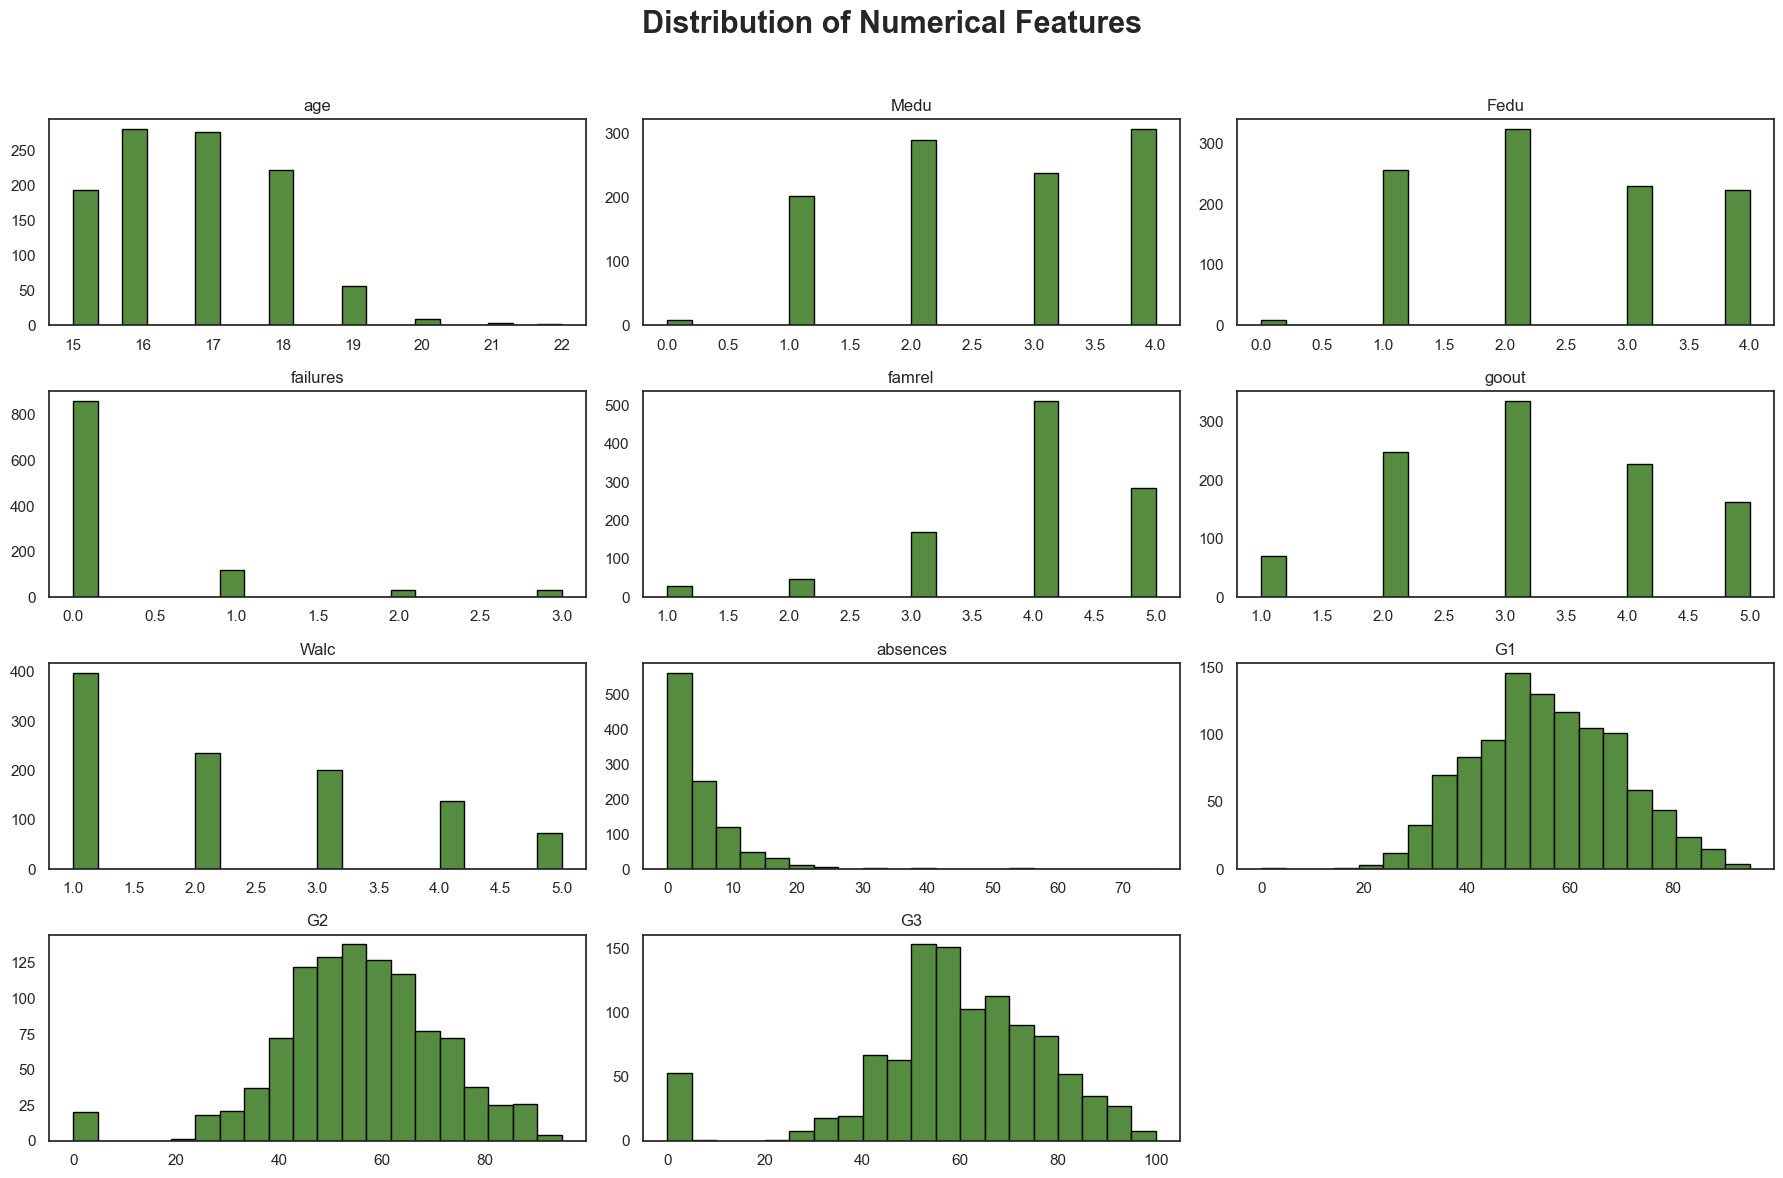

In [51]:
sns.set_style("white")

# Sayısal kolonlar
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Histogramlar
df[numeric_cols].hist(
    figsize=(18, 12),
    bins=20,
    color="#558C3F",      # hoş mavi tonu
    edgecolor="black",
    linewidth=1
)

# Başlık
plt.suptitle(
    "Distribution of Numerical Features",
    fontsize=22,
    fontweight='bold'
)

# Grid kaldır
for ax in plt.gcf().axes:
    ax.grid(False)

plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.show()

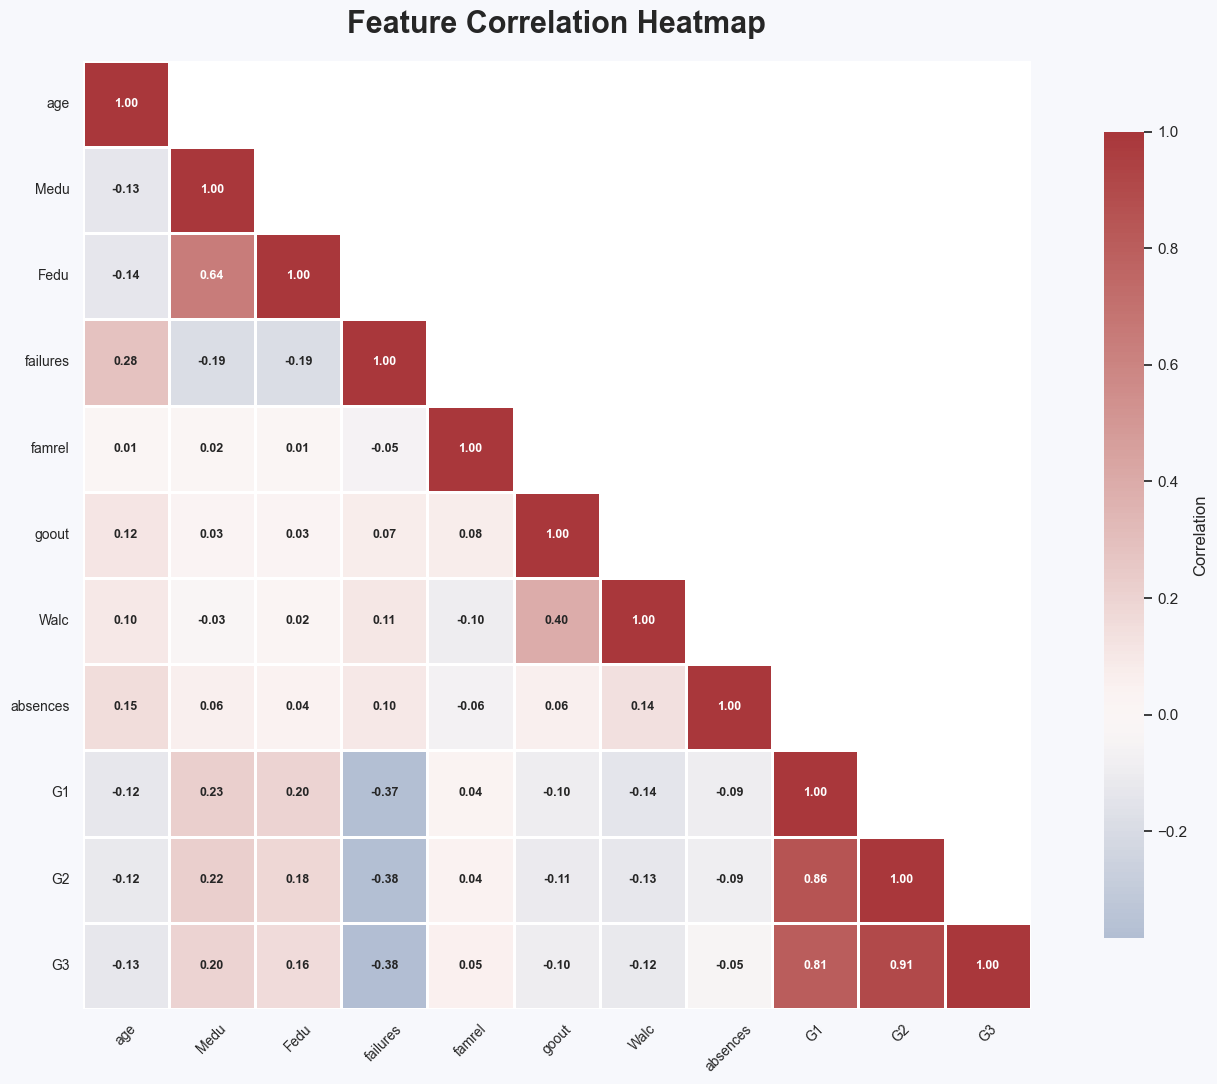

In [33]:
# Korelasyon matrisi
corr = df.corr(numeric_only=True)

# Üst üçgeni gizle
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

# Daha temiz görsel stil
sns.set_theme(style="white", context="notebook")
plt.figure(figsize=(15, 11), facecolor="#f7f8fc")

# Heatmap
ax = sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0,
    square=True,
    linewidths=1.0,
    linecolor="white",
    cbar_kws={"shrink": 0.85, "label": "Correlation"},
    annot_kws={"size": 9, "weight": "bold"},
)

# Başlık ve eksenler
ax.set_title(
    "Feature Correlation Heatmap",
    fontsize=22,
    fontweight="bold",
    pad=20
)

ax.tick_params(axis="x", rotation=45, labelsize=10)
ax.tick_params(axis="y", rotation=0, labelsize=10)

# Çerçeve sadeleştirme
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

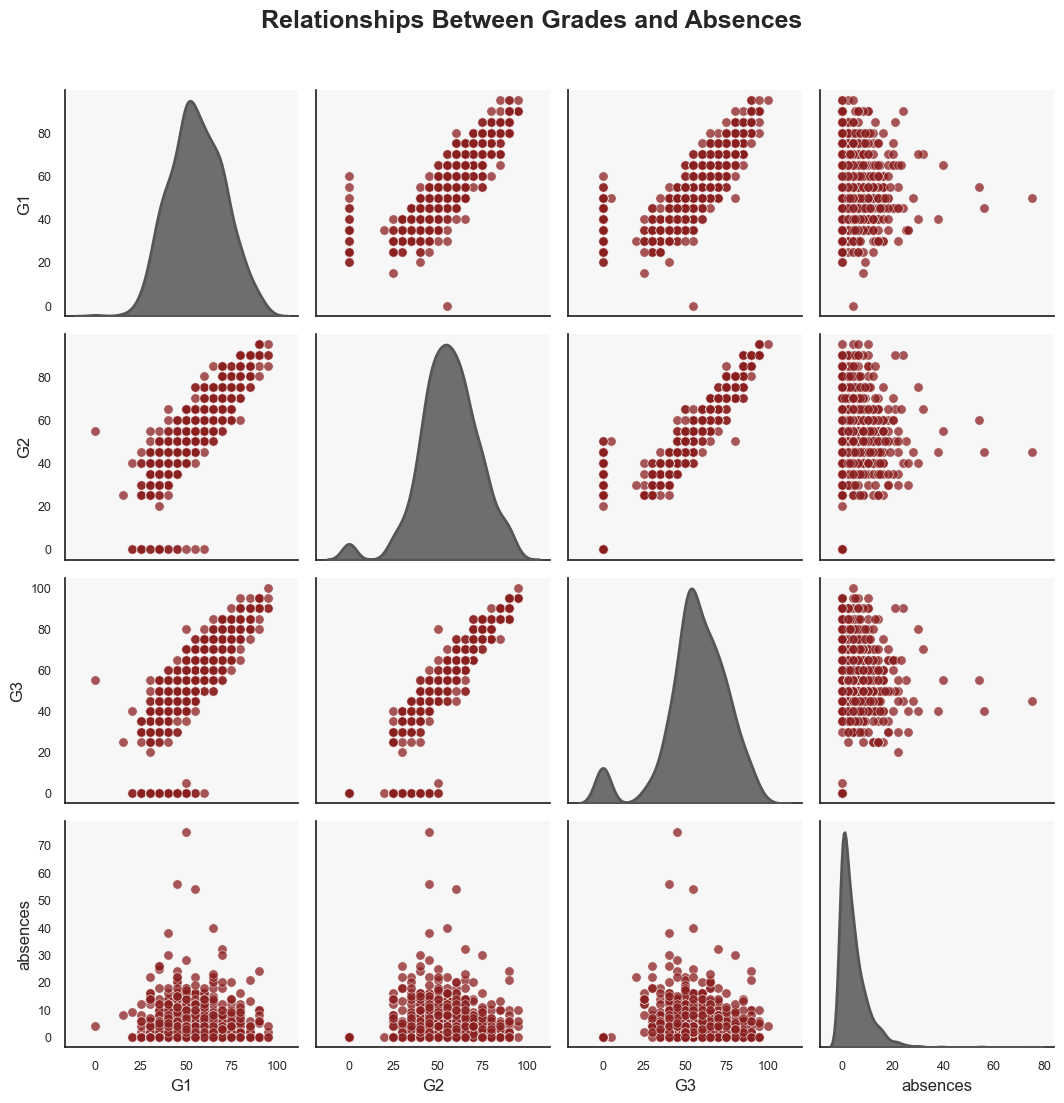

In [49]:
cols = ["G1", "G2", "G3", "absences"]

sns.set_theme(style="white", context="notebook")

g = sns.pairplot(
    df[cols],
    diag_kind="kde",
    corner=False,
    height=2.7,
    plot_kws={
        "alpha": 0.75,
        "s": 45,
        "color": "#8A1F1F",
        "edgecolor": "white",
        "linewidth": 0.4
    },
    diag_kws={
        "fill": True,
        "color": "#565656",
        "linewidth": 2,
        "alpha": 0.85
    }
)

g.fig.suptitle(
    "Relationships Between Grades and Absences",
    y=1.02,
    fontsize=18,
    fontweight="bold"
)

for ax in g.axes.flatten():
    if ax is not None:
        ax.grid(False)
        ax.set_facecolor("#F7F7F7")
        ax.tick_params(labelsize=9)

plt.tight_layout()
plt.show()